In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io as sio
from scipy.optimize import curve_fit
import warnings

import RamanHelpers as rh

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.dpi"       : 150,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Save helper ───────────────────────────────────────────────────────────────
SAVE_FILE = "calibration_results.npz"

def save_results(**kwargs):
    """
    Incrementally update calibration_results.npz with new key-value pairs.
    Loads existing data first so no previous results are lost.
    """
    store = dict(np.load(SAVE_FILE, allow_pickle=True)) \
            if os.path.exists(SAVE_FILE) else {}
    store.update(kwargs)
    np.savez(SAVE_FILE, **store)
    keys = list(kwargs.keys())
    print(f"  ✓ Saved {len(keys)} variable(s) → {SAVE_FILE}")
    print(f"    {keys}")

print("Imports OK")
print(f"Save file  : {SAVE_FILE}")
print(f"rh version : {rh.__file__}")

Imports OK
Save file  : calibration_results.npz
rh version : /Users/egeeroglu/Desktop/RIRO/Tuesday/RamanData/RamanHelpers.py


In [3]:
# ── Cell 2: Constants and dataset definitions ─────────────────────────────────
# All magic numbers in one place — change here, propagates everywhere.

# ── Dataset paths ─────────────────────────────────────────────────────────────
datasets = {
    "GrapheneMap20" : "GrapheneMap20.0.mat",   # main Raman map  (20×20)
    "SiGrid20Line"  : "SiGrid20Line.0.mat",    # line scan, 20 µm grid
    "SiGrid50Line"  : "SiGrid50Line.0.mat",    # line scan, 50 µm grid
}

# ── Si calibration constants ──────────────────────────────────────────────────
SI_REF   = 520.0   # cm⁻¹  true Si first-order phonon position
SI_LO    = 480.0   # cm⁻¹  fit window lower bound
SI_HI    = 560.0   # cm⁻¹  fit window upper bound
BL_LEFT  = 490.0   # cm⁻¹  left  baseline anchor (upper edge of window)
BL_RIGHT = 550.0   # cm⁻¹  right baseline anchor (lower edge of window)

# ── Helper aliases from raman_helpers ────────────────────────────────────────
lorentzian      = rh.lorentzian
linear_baseline = rh.linear_baseline
crop            = rh.crop

# ── Sanity check — verify all files exist before running ─────────────────────
print("── Datasets ──────────────────────────────────────────────────────────")
for name, path in datasets.items():
    exists = os.path.exists(path)
    status = "✓ found" if exists else "✗ NOT FOUND"
    print(f"  {name:<18} {path:<28} {status}")

print(f"\n── Si calibration constants ──────────────────────────────────────────")
print(f"  SI_REF      = {SI_REF} cm⁻¹")
print(f"  Fit window  = {SI_LO} – {SI_HI} cm⁻¹")
print(f"  Baseline    = anchored at {BL_LEFT} and {BL_RIGHT} cm⁻¹")

── Datasets ──────────────────────────────────────────────────────────
  GrapheneMap20      GrapheneMap20.0.mat          ✓ found
  SiGrid20Line       SiGrid20Line.0.mat           ✓ found
  SiGrid50Line       SiGrid50Line.0.mat           ✓ found

── Si calibration constants ──────────────────────────────────────────
  SI_REF      = 520.0 cm⁻¹
  Fit window  = 480.0 – 560.0 cm⁻¹
  Baseline    = anchored at 490.0 and 550.0 cm⁻¹



── GrapheneMap20 ──
  si_cen_raw  : 521.081 ± 0.091 cm⁻¹
  si_fwhm     : 11.008 ± 0.258 cm⁻¹
  si_offset   : +1.081 cm⁻¹  →  ~ acceptable

── SiGrid20Line ──
  si_cen_raw  : 520.537 ± 0.020 cm⁻¹
  si_fwhm     : 4.537 ± 0.058 cm⁻¹
  si_offset   : +0.537 cm⁻¹  →  ✓ OK

── SiGrid50Line ──
  si_cen_raw  : 520.403 ± 0.021 cm⁻¹
  si_fwhm     : 4.541 ± 0.060 cm⁻¹
  si_offset   : +0.403 cm⁻¹  →  ✓ OK


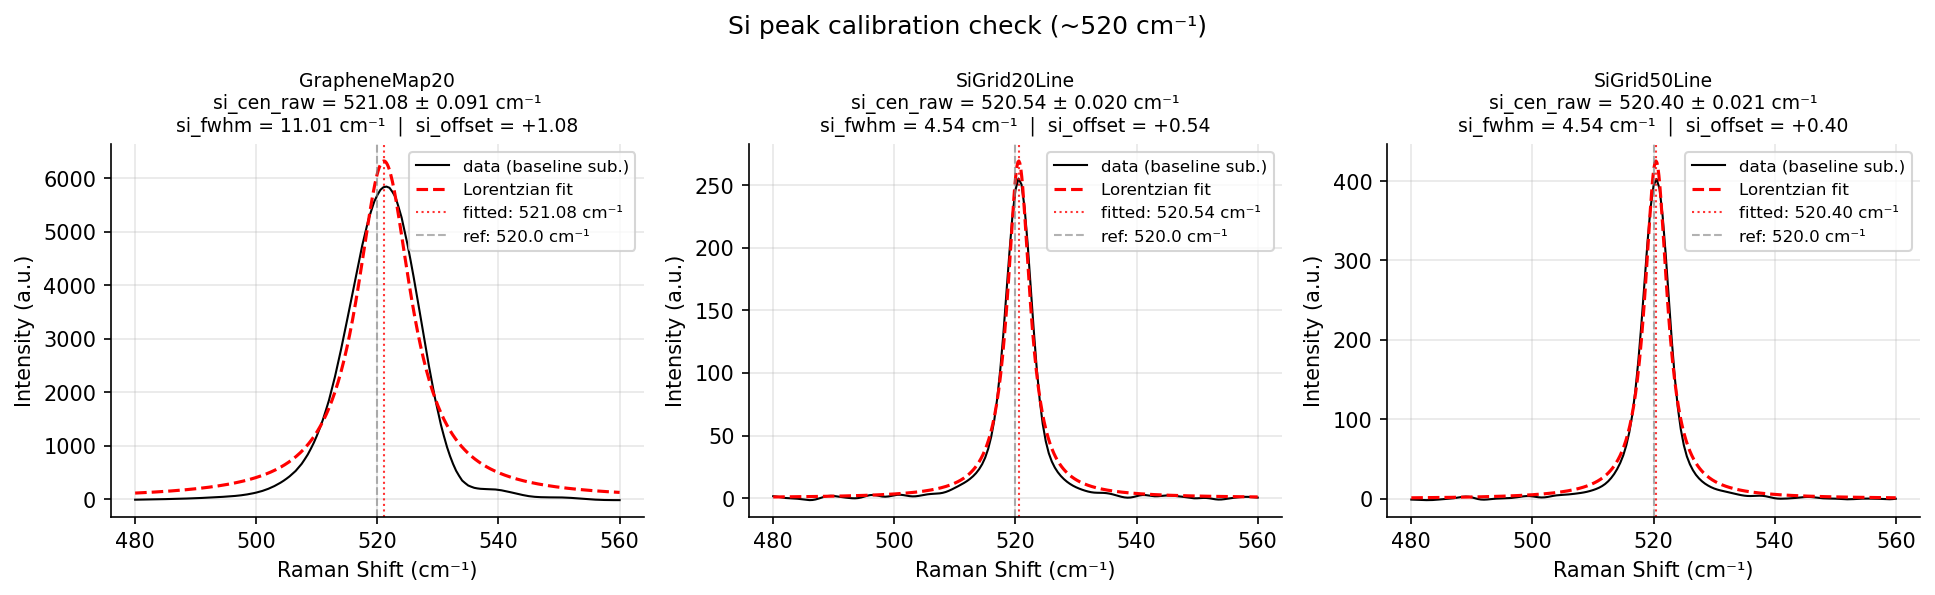

Saved: 00_Si_calibration.png

  cal_offset (main analysis) = +1.081 cm⁻¹
  ✓ Saved 16 variable(s) → calibration_results.npz
    ['si_cen_raw_GrapheneMap20', 'si_fwhm_GrapheneMap20', 'si_offset_GrapheneMap20', 'si_cen_err_GrapheneMap20', 'si_fwhm_err_GrapheneMap20', 'si_cen_raw_SiGrid20Line', 'si_fwhm_SiGrid20Line', 'si_offset_SiGrid20Line', 'si_cen_err_SiGrid20Line', 'si_fwhm_err_SiGrid20Line', 'si_cen_raw_SiGrid50Line', 'si_fwhm_SiGrid50Line', 'si_offset_SiGrid50Line', 'si_cen_err_SiGrid50Line', 'si_fwhm_err_SiGrid50Line', 'cal_offset']


In [4]:
# ── Cell 3: Si peak calibration ───────────────────────────────────────────────
# Fits the Si first-order phonon peak (~520 cm⁻¹) on the mean spectrum
# of each dataset. Any deviation from SI_REF is the wavenumber axis offset
# (CAL_OFFSET) that must be subtracted from all reported peak centres.
#
# Naming convention:
#   si_cen_raw_{name}  → raw fitted Si centre (cm⁻¹)
#   si_fwhm_{name}     → fitted Si FWHM (cm⁻¹)
#   si_offset_{name}   → deviation from SI_REF = CAL_OFFSET
#   si_cen_err_{name}  → 1-sigma fit uncertainty on centre
#   si_fwhm_err_{name} → 1-sigma fit uncertainty on FWHM
#   cal_offset         → GrapheneMap20 offset, used by main analysis notebook

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Si peak calibration check (~520 cm⁻¹)", fontsize=12)

cal_results = {}

for ax, (name, fname) in zip(axes, datasets.items()):

    # 1. Load
    mat      = sio.loadmat(fname)
    Ra       = mat["Ra"]
    wn_full  = Ra[:, 0]
    spectra  = Ra[:, 1:]

    # 2. Average all spectra — better SNR than any single spectrum
    mean_spec = spectra.mean(axis=1)

    # 3. Crop to Si region
    wn_si, sp_si = rh.crop(wn_full, mean_spec, SI_LO, SI_HI)

    # 4. Subtract linear baseline
    bl    = rh.linear_baseline(wn_si, sp_si, BL_LEFT, BL_RIGHT)
    sp_bl = sp_si - bl

    # 5. Fit Lorentzian
    p0     = [sp_bl.max(), 521.0, 5.0]
    bounds = ([0, 500, 1], [np.inf, 540, 30])
    fit_ok = False
    try:
        popt, pcov = curve_fit(rh.lorentzian, wn_si, sp_bl,
                               p0=p0, bounds=bounds, maxfev=5000)
        perr                       = np.sqrt(np.diag(pcov))
        amp,     cen,      fwhm     = popt
        amp_err, cen_err,  fwhm_err = perr
        fit_ok = True
    except RuntimeError:
        print(f"{name}: Lorentzian fit did not converge")

    # 6. Store and print
    if fit_ok:
        offset = cen - SI_REF
        cal_results[name] = {
            "si_cen_raw"  : cen,
            "si_fwhm"     : fwhm,
            "si_offset"   : offset,
            "si_cen_err"  : cen_err,
            "si_fwhm_err" : fwhm_err,
        }

        status = ("✓ OK"         if abs(offset) < 1.0 else
                  "~ acceptable" if abs(offset) < 2.0 else
                  "✗ recalibrate")

        print(f"\n── {name} ──")
        print(f"  si_cen_raw  : {cen:.3f} ± {cen_err:.3f} cm⁻¹")
        print(f"  si_fwhm     : {fwhm:.3f} ± {fwhm_err:.3f} cm⁻¹")
        print(f"  si_offset   : {offset:+.3f} cm⁻¹  →  {status}")

    # 7. Plot
    ax.plot(wn_si, sp_bl, "k", lw=1, label="data (baseline sub.)")
    if fit_ok:
        wn_fit = np.linspace(wn_si[0], wn_si[-1], 500)
        ax.plot(wn_fit, rh.lorentzian(wn_fit, *popt),
                "r--", lw=1.5, label="Lorentzian fit")
        ax.axvline(cen,    color="red",  lw=1, ls=":",
                   alpha=0.8, label=f"fitted: {cen:.2f} cm⁻¹")
        ax.axvline(SI_REF, color="gray", lw=1, ls="--",
                   alpha=0.6, label=f"ref: {SI_REF:.1f} cm⁻¹")
        ax.set_title(
            f"{name}\n"
            f"si_cen_raw = {cen:.2f} ± {cen_err:.3f} cm⁻¹\n"
            f"si_fwhm = {fwhm:.2f} cm⁻¹  |  si_offset = {offset:+.2f}",
            fontsize=9
        )
    ax.set_xlabel("Raman Shift (cm⁻¹)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("00_Si_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 00_Si_calibration.png")

# ── Save ──────────────────────────────────────────────────────────────────────
save_dict = {}
for name, r in cal_results.items():
    for key, val in r.items():
        save_dict[f"{key}_{name}"] = val

if "GrapheneMap20" in cal_results:
    save_dict["cal_offset"] = cal_results["GrapheneMap20"]["si_offset"]
    print(f"\n  cal_offset (main analysis) = "
          f"{save_dict['cal_offset']:+.3f} cm⁻¹")

save_results(**save_dict)